## Business Objective:

As we know the concept of Data science and ML is useful in many of the domains, in which one of the emerging domains is Automobile. As we can upfront build predictive models to forecast the revenue of the company, loyal customers analysis. Survival period of the machines etc and a lot of analysis we can perform and prescribe too.

Now we are working on the cars segment where a lot of purchases and sales increased rapidly especially because of the COVID. So, we have a requirement like what's the revenue made by companies like cars24, carwale, spinny even their company margin also increase predominantly. So that if a client establishes the business whether they can survive in the present market, and at what % of market share will be hold by the different companies.

So, we are considering cars 24 websites to scrape the data and perform the analysis.
Important steps to perform are:
    Load dataset
    Data pre-processing
    Eda
    Model performing
    Deployment


## Objective:Predict Car Price

Importing all the important Libraries.
For importing the data reading it.
Data manipulation performing arithematic computation.
Performing statistical operations.
Importing libraries to perform data visualisation in 2D and 3D.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

In [3]:
import os

# Create 'artifacts' and 'logs' directories if they don't exist
os.makedirs('artifacts', exist_ok=True)
os.makedirs('logs', exist_ok=True)
print("Created 'artifacts' and 'logs' directories.")

Created 'artifacts' and 'logs' directories.


In [4]:
# Move the original dataset into the data folder if it exists in the root
if os.path.exists('cars24_data.csv'):
    os.rename('cars24_data.csv', 'data/cars24_data.csv')
    print('Moved cars24_data.csv to data/')


### Saving Preprocessing Objects and Model

In [5]:
# Move the original dataset into the data folder if it exists in the root
if os.path.exists('cars24_data.csv'):
    os.rename('cars24_data.csv', 'data/cars24_data.csv')
    print('Moved cars24_data.csv to data/')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Importing the  file and reading the datframes

In [7]:
cars_df =pd.read_csv('data/cars24_data.csv')

In [8]:
cars_df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [9]:
#Checking for the shape of the file
cars_df.shape

(6437, 19)

In [10]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 non-null   int64 


In [11]:
#checking for duplicate values
cars_df.duplicated().sum()

np.int64(15)

In [12]:
#displaying the duplicate values
cars_df[cars_df.duplicated()]

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
2080,Maruti Baleno,Maruti,Baleno,Coimbatore,2017,Petrol,33676,1,Manual,Hatchback,Hi-Chennai Central,False,Chennai South,Tamil Nadu,9688,41900,661000,https://www.cars24.com/buy-used-maruti-baleno-...,2022-07-15
6284,Mahindra Thar,Mahindra,Thar,Mumbai,2021,Petrol,2443,1,NaN,NaN,Hi-West Mumbai,False,Mumbai,Maharashtra,9688,0,1512000,https://www.cars24.com/buy-used-mahindra-thar-...,2022-12-09
6285,Maruti Ciaz,Maruti,Ciaz,Bangalore,2016,Petrol,60209,2,Manual,Sedan,Hi-South 2 Bengaluru,False,Bangalore,Karnataka,9688,0,713000,https://www.cars24.com/buy-used-maruti-ciaz-20...,2022-12-09
6292,Hyundai Grand i10,Hyundai,Grand I10,Bangalore,2014,Petrol,56757,1,Manual,Hatchback,Bengaluru-Pns,False,Udupi,Karnataka,13898,0,471000,https://www.cars24.com/buy-used-hyundai-grand-...,2022-12-09
6301,Maruti Ciaz,Maruti,Ciaz,New Delhi,2018,Petrol,21776,1,Manual,Sedan,Hi-Yamuna Bank Delhi,False,New Delhi,Delhi,9688,0,725000,https://www.cars24.com/buy-used-maruti-ciaz-20...,2022-12-10
6303,Maruti Alto K10,Maruti,Alto K10,Hyderabad,2019,Petrol,18653,1,Automatic,Hatchback,Hyderabad-Pns,False,Hyderabad,Telangana,12542,0,460000,https://www.cars24.com/buy-used-maruti-alto-k1...,2022-12-10
6340,Maruti Swift,Maruti,Swift,Chandigarh,2017,Petrol,34903,1,Manual,Hatchback,Chandigarh-Pns,False,Chandigarh,Chandigarh,13898,0,600000,https://www.cars24.com/buy-used-maruti-swift-2...,2022-12-10
6360,Maruti Wagon R 1.0,Maruti,Wagon R 1.0,Mumbai,2017,Petrol + Cng,14484,1,Manual,Hatchback,Hi-Thane West - Manpada,False,Mumbai,Maharashtra,9688,0,454000,https://www.cars24.com/buy-used-maruti-wagon-r...,2022-12-09
6361,Maruti Swift Dzire,Maruti,Swift Dzire,Hyderabad,2013,Petrol,56714,2,Automatic,Sedan,Hi-West Hyd,False,Hyderabad,Telangana,9688,0,500000,https://www.cars24.com/buy-used-maruti-swift-d...,2022-12-09
6362,Maruti Celerio,Maruti,Celerio,Patna,2015,Petrol,45499,2,Manual,Hatchback,Shaguna More,False,Patna,Bihar,12542,0,316000,https://www.cars24.com/buy-used-maruti-celerio...,2022-12-09


In [13]:
#removing the duplicated rows
cars_df.drop_duplicates(inplace=True)

In [14]:
#checking for the shape of the dataframe
cars_df.shape

(6422, 19)

#15 Duplicate rows were dropped

In [15]:
#Checking for null values
cars_df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         375
bodytype             374
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
dtype: int64

In [16]:
#replacing the null values for categorical columns with mode
cars_df['transmission'].fillna(cars_df['transmission'].mode()[0], inplace=True)
cars_df['bodytype'].fillna(cars_df['bodytype'].mode()[0], inplace=True)

In [17]:
#checking for null values again
cars_df.isnull().sum()

name                 0
make                 0
model                0
city                 0
year                 0
fueltype             0
kilometerdriven      0
ownernumber          0
transmission         0
bodytype             0
storename            0
isc24assured         0
registrationcity     0
registrationstate    0
benefits             0
discountprice        0
price                0
url                  0
createdDate          0
dtype: int64

All Null values have been removed

In [18]:
#checking unique values for all categorical columns
for cols in cars_df.select_dtypes('object'):
      print("---------")
      print(f'{cols}-->{cars_df[cols].nunique()}')

---------
name-->135
---------
make-->20
---------
model-->134
---------
city-->41
---------
fueltype-->3
---------
transmission-->2
---------
bodytype-->6
---------
storename-->203
---------
registrationcity-->358
---------
registrationstate-->16
---------
url-->6422
---------
createdDate-->310


In [19]:
cars_df['benefits'].nunique()

5

In [20]:
#Converting CreateDate from categorical to date
cars_df['createdDate'] = pd.to_datetime(cars_df['createdDate'])

In [21]:
#Checking Negative discounted value and removing negative discount value
cars_df['discountprice'] = cars_df['discountprice'].clip(lower=0)
cars_df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [22]:
#Renaming Price as Actual Price and deriving Selling Proce from it
cars_df.rename(columns={'price': 'Actual_price'}, inplace=True)

## Feature Engineering

In [23]:
#Calculaing the age of the car or Performing feature Engineering
cars_df['car_age'] =cars_df['createdDate'].dt.year-cars_df['year']

In [24]:
cars_df['Selling_Price'] =cars_df['Actual_price']-cars_df['discountprice']

In [25]:
cars_df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,...,isc24assured,registrationcity,registrationstate,benefits,discountprice,Actual_price,url,createdDate,car_age,Selling_Price
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,...,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24,5,559601
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,...,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09,6,323901
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,...,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30,3,614000
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,...,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04,2,1210300
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,...,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28,5,653200


## Performing EDA on the DATA and Visualization to identify the relationship between variables

## Visualizations

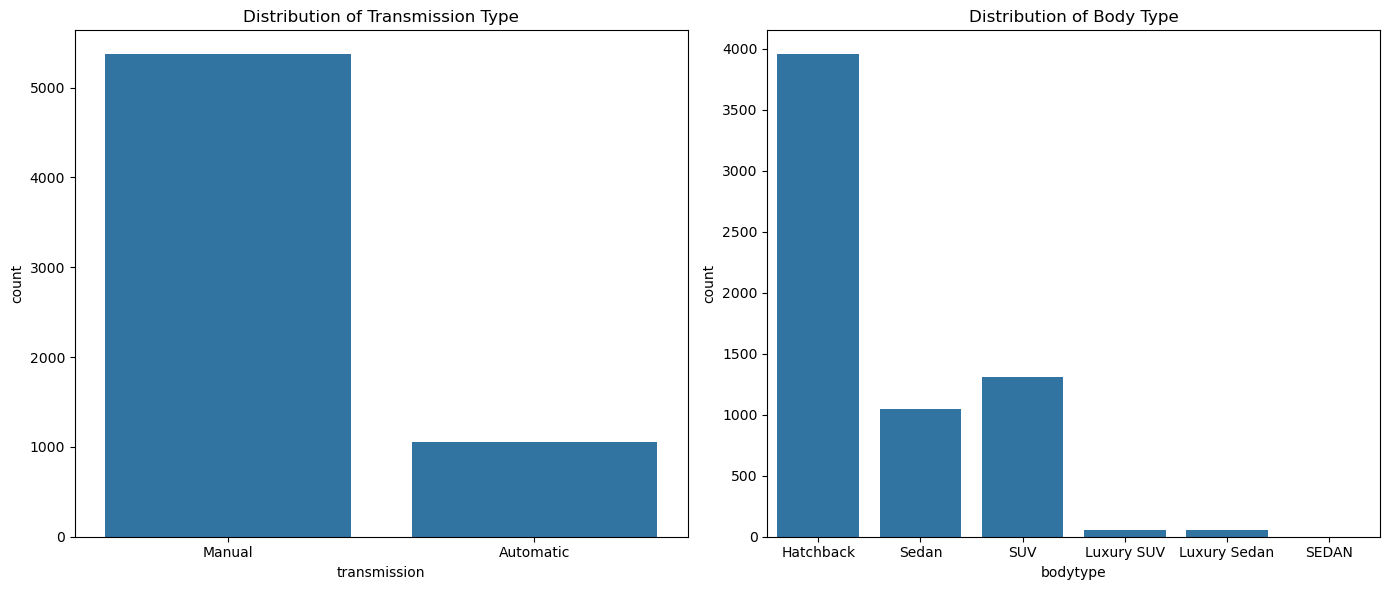

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=cars_df, x='transmission', ax=axes[0])
axes[0].set_title('Distribution of Transmission Type')
sns.countplot(data=cars_df, x='bodytype', ax=axes[1])
axes[1].set_title('Distribution of Body Type')
plt.tight_layout()
plt.show()

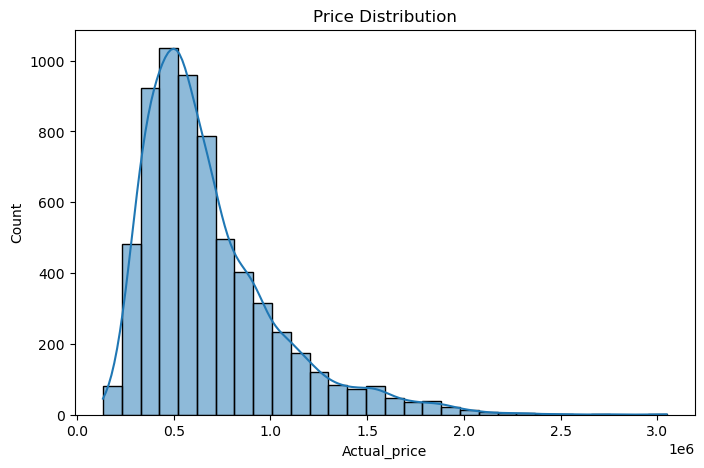

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(cars_df['Actual_price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

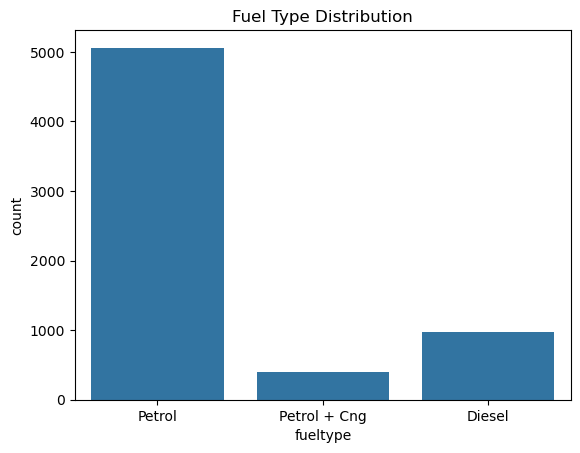

In [28]:
sns.countplot(x='fueltype', data=cars_df)
plt.title("Fuel Type Distribution")
plt.show()

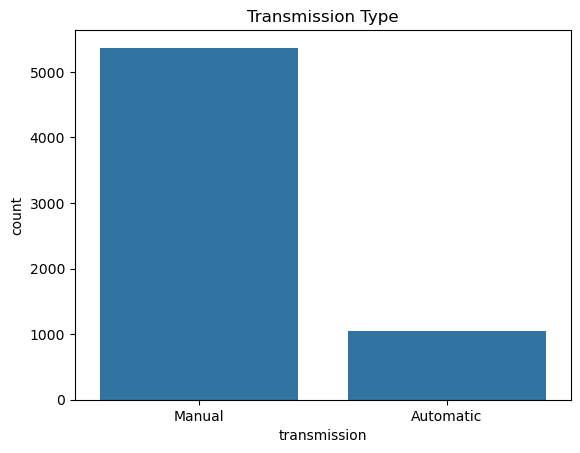

In [29]:
sns.countplot(x='transmission', data=cars_df)
plt.title("Transmission Type")
plt.show()

## Bivariate and Multivariate Analysis

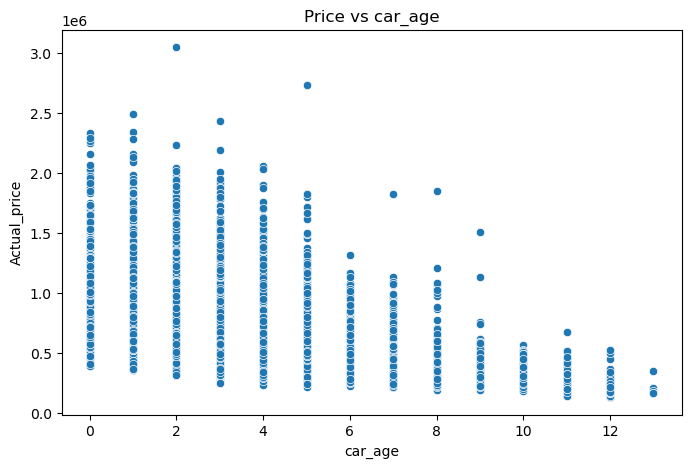

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='car_age', y='Actual_price', data=cars_df)
plt.title("Price vs car_age")
plt.show()

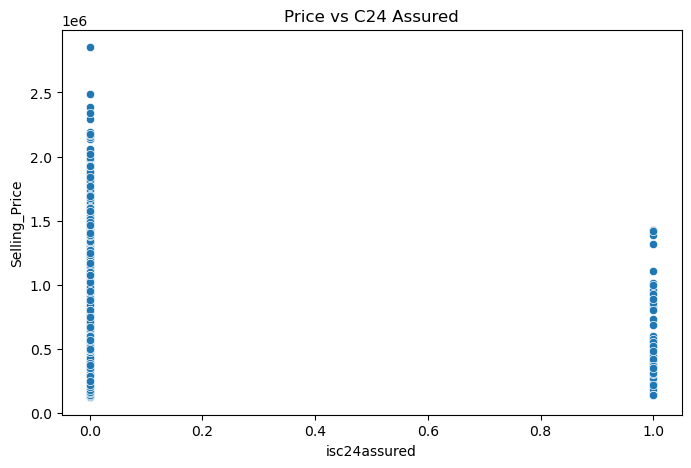

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='isc24assured', y='Selling_Price', data=cars_df)
plt.title("Price vs C24 Assured")
plt.show()

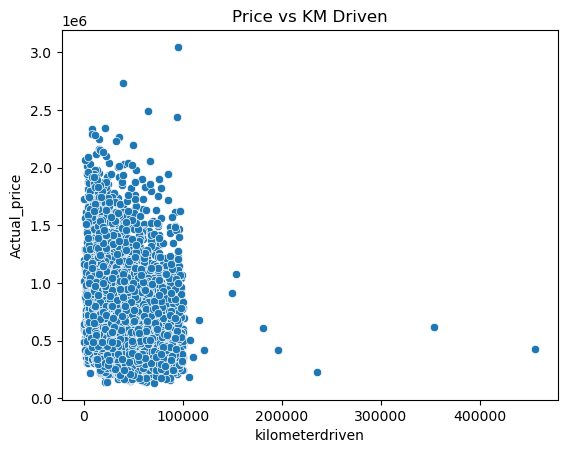

In [32]:
sns.scatterplot(x='kilometerdriven', y='Actual_price', data=cars_df)
plt.title("Price vs KM Driven")
plt.show()

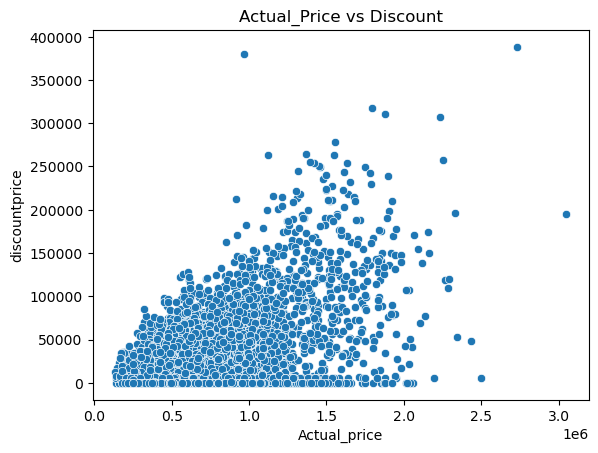

In [33]:
sns.scatterplot(x='Actual_price', y='discountprice', data=cars_df)
plt.title("Actual_Price vs Discount")
plt.show()

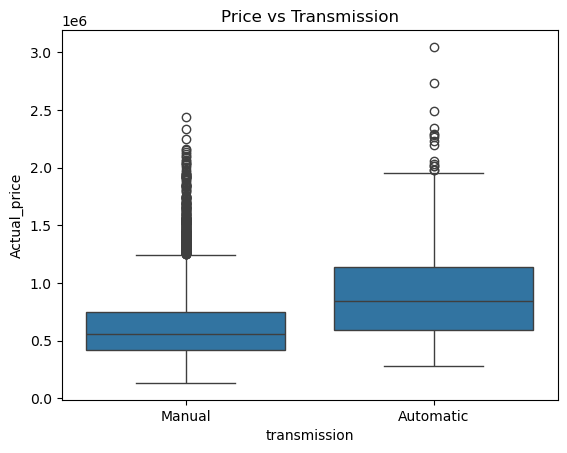

In [34]:
sns.boxplot(x='transmission', y='Actual_price', data=cars_df)
plt.title("Price vs Transmission")
plt.show()

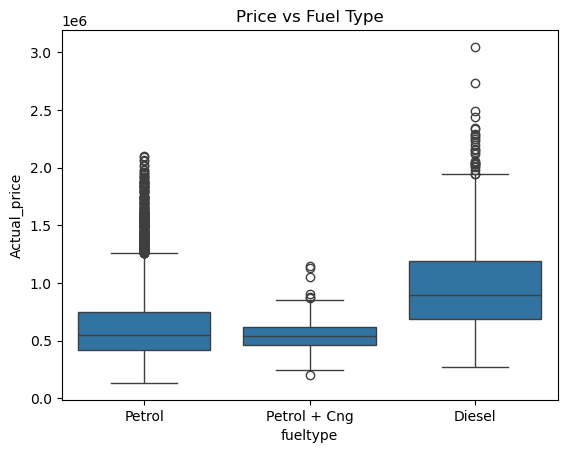

In [35]:
sns.boxplot(x='fueltype', y='Actual_price', data=cars_df)
plt.title("Price vs Fuel Type")
plt.show()

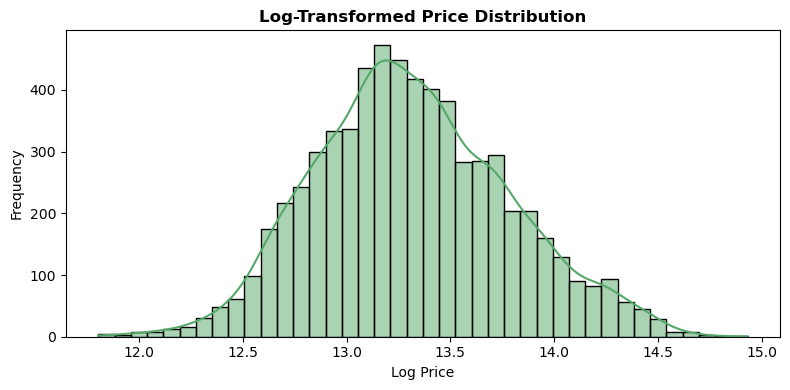

In [36]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(cars_df['Actual_price']), kde=True, color='#55A868', bins=40)
plt.title("Log-Transformed Price Distribution", fontweight='bold')
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

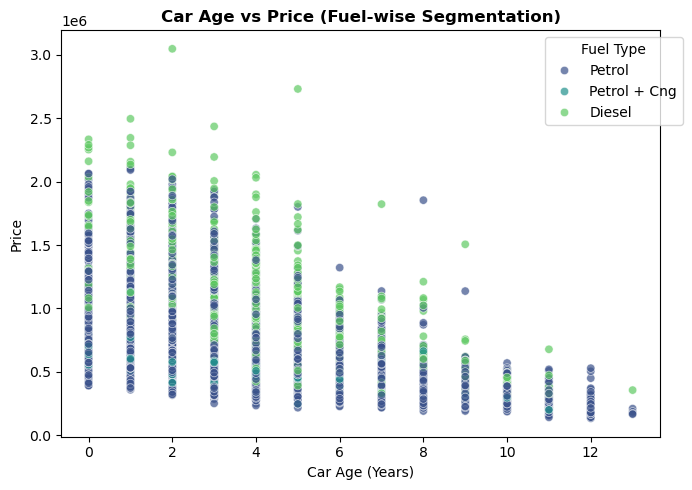

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='car_age',
    y='Actual_price',
    data=cars_df,
    hue='fueltype',
    palette='viridis',
    alpha=0.7
)
plt.title("Car Age vs Price (Fuel-wise Segmentation)", fontweight='bold')
plt.xlabel("Car Age (Years)")
plt.ylabel("Price")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

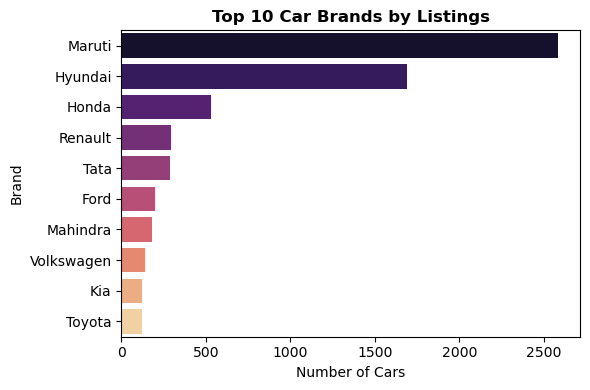

In [38]:
plt.figure(figsize=(6,4))
top_brands = cars_df['make'].value_counts().head(10)
sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette='magma'
)
plt.title("Top 10 Car Brands by Listings", fontweight='bold')
plt.xlabel("Number of Cars")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

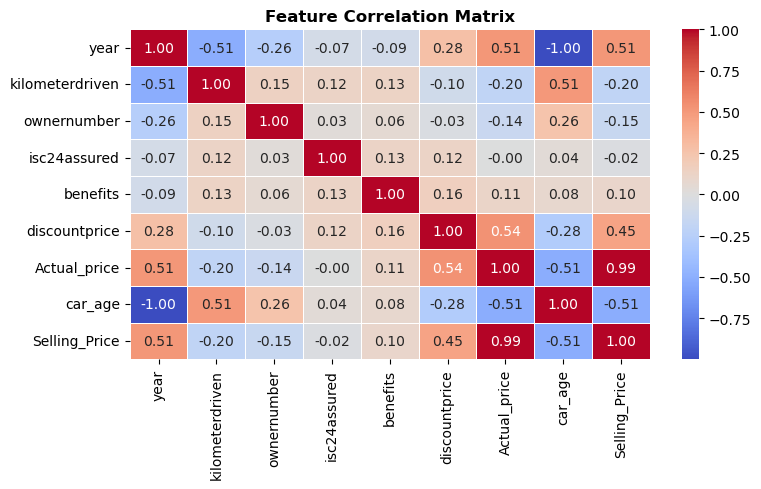

In [39]:
plt.figure(figsize=(8,5))
sns.heatmap(
    cars_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

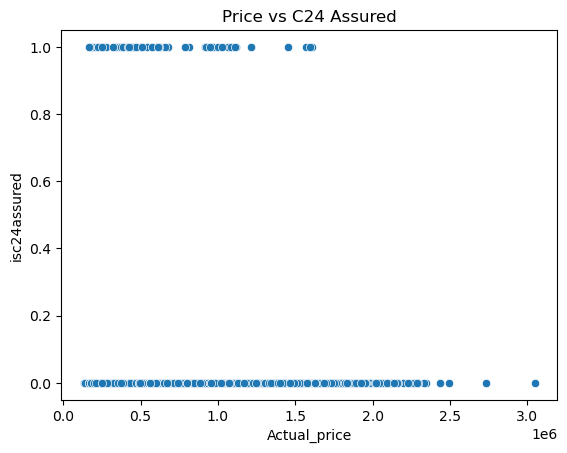

In [40]:
sns.scatterplot(y='isc24assured', x='Actual_price', data=cars_df)
plt.title("Price vs C24 Assured")
plt.show()

Analysis: Key Findings from Bivariate and Multivariate Analysis
-------------------------------------------------------------
1. Temporal trends:
   - Cars sold after 2016 show higher volume and price points.
   - Based on the above graphs it can be inferred that maximum cars for sale are Manual Transmission with a Price range of 0.5lakhs to 1.5lakhs of fuel type petrol.

3. Mileage impact:
   - Cars with <100,000 km have higher sales probability
   - Sales likelihood decreases significantly beyond 100,000 km threshold
  
3. Transmission type pricing differences:
   - Manual transmission cars sell at lower prices (max ~₹1.25 lakh)
   - Automatic transmission cars command premium prices (up to ~₹2 lakh)
   - Hybrid and petrol cars show similar average price points
  
4. Age-related factors:
   - Car depreciation strongly influences resale value
   - Car age appears to be a critical predictive feature
   - Negative correlation between car age and both sales volume and price
    
5. Brand distribution:
    - Dataset shows concentration among popular brands (Maruti, Hyundai, Honda)
  
7. Also the cars that are not car24 Assured has no correlation with price, hence can be dropped

8. Predictive modeling implications:
    - Correlation analysis suggests multiple features contribute to price determination
    - No single dominant feature explains pricing variance
9. Based on the Correlation Matrix:

10. There is a similar correlation between Age of car and year

11. There is a similar correlation between selling Price and actual Price

12. IsC24assured does not contribute to the price

13. Also the values for City and Regitration City Similar

## Dropping Unwanted Columns

In [41]:
cars_df = cars_df.drop(['url'], axis=1)

In [42]:
cars_df = cars_df.drop(['benefits'], axis=1)

In [43]:
cars_df = cars_df.drop(['name'], axis=1)

In [44]:
cars_df = cars_df.drop(['storename'], axis=1)

In [45]:
cars_df = cars_df.drop(['city'], axis=1)

In [46]:
cars_df = cars_df.drop(['isc24assured'], axis=1)

In [47]:
cars_df = cars_df.drop(['car_age'], axis=1)

In [48]:
cars_df = cars_df.drop(['discountprice'], axis=1)

In [49]:
cars_df = cars_df.drop(['Actual_price'], axis=1)

In [50]:
cars_df = cars_df.drop(['createdDate'], axis=1)

In [51]:
cars_df.head()

,make,model,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,registrationcity,registrationstate,Selling_Price
0,Hyundai,Elite I20,2017,Petrol,35939,2,Manual,Hatchback,Kozhikode,Kerala,559601
1,Maruti,Alto 800,2016,Petrol + Cng,6180,1,Manual,Hatchback,Mumbai,Maharashtra,323901
2,Maruti,Dzire,2019,Petrol + Cng,46808,1,Manual,Sedan,Lucknow,Uttar Pradesh,614000
3,Kia,Seltos,2020,Diesel,26045,1,Manual,SUV,Bengaluru,Karnataka,1210300
4,Maruti,Ertiga,2017,Petrol,53056,1,Manual,SUV,Barrackpore,West Bengal,653200


In [52]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6422 entries, 0 to 6436
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   make               6422 non-null   object
 1   model              6422 non-null   object
 2   year               6422 non-null   int64 
 3   fueltype           6422 non-null   object
 4   kilometerdriven    6422 non-null   int64 
 5   ownernumber        6422 non-null   int64 
 6   transmission       6422 non-null   object
 7   bodytype           6422 non-null   object
 8   registrationcity   6422 non-null   object
 9   registrationstate  6422 non-null   object
 10  Selling_Price      6422 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 602.1+ KB


## Data Preprocessing

In [53]:
numerical_cols = ['year','kilometerdriven','Selling_Price']
cat_cols = ['make', 'model','fueltype','ownernumber','transmission','bodytype','registrationcity','registrationstate']

Handling Outliers

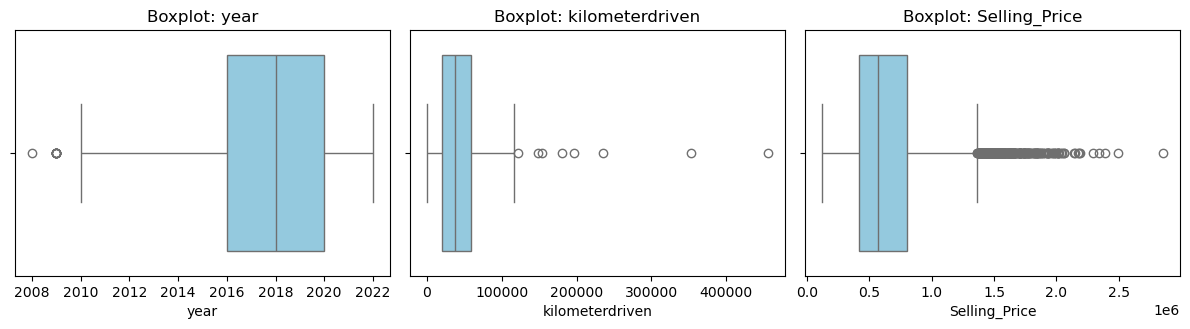

In [54]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=cars_df[col], color="skyblue")  #Plot Boxplot For Outlier Detection
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [55]:
cars_df_new = cars_df.copy()

for col in numerical_cols :
    Q1 = cars_df_new[col].quantile(0.25)
    Q3 = cars_df_new[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = cars_df_new[(cars_df_new[col] < lower_bound) | (cars_df_new[col] > upper_bound)] #Identify Outliers Based on IQR Method
    print(f'{len(outliers)} Outliers in {col}')

10 Outliers in year
8 Outliers in kilometerdriven
283 Outliers in Selling_Price


In [56]:
for col in numerical_cols :
    Q1 = cars_df_new[col].quantile(0.25)
    Q3 = cars_df_new[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cars_df_new[col] = cars_df_new[col].apply(lambda x: max(min(x, upper_bound), lower_bound))
    # capping For handling Outliers

In [57]:
cars_df_new.head()

,make,model,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,registrationcity,registrationstate,Selling_Price
0,Hyundai,Elite I20,2017.0,Petrol,35939.0,2,Manual,Hatchback,Kozhikode,Kerala,559601.0
1,Maruti,Alto 800,2016.0,Petrol + Cng,6180.0,1,Manual,Hatchback,Mumbai,Maharashtra,323901.0
2,Maruti,Dzire,2019.0,Petrol + Cng,46808.0,1,Manual,Sedan,Lucknow,Uttar Pradesh,614000.0
3,Kia,Seltos,2020.0,Diesel,26045.0,1,Manual,SUV,Bengaluru,Karnataka,1210300.0
4,Maruti,Ertiga,2017.0,Petrol,53056.0,1,Manual,SUV,Barrackpore,West Bengal,653200.0


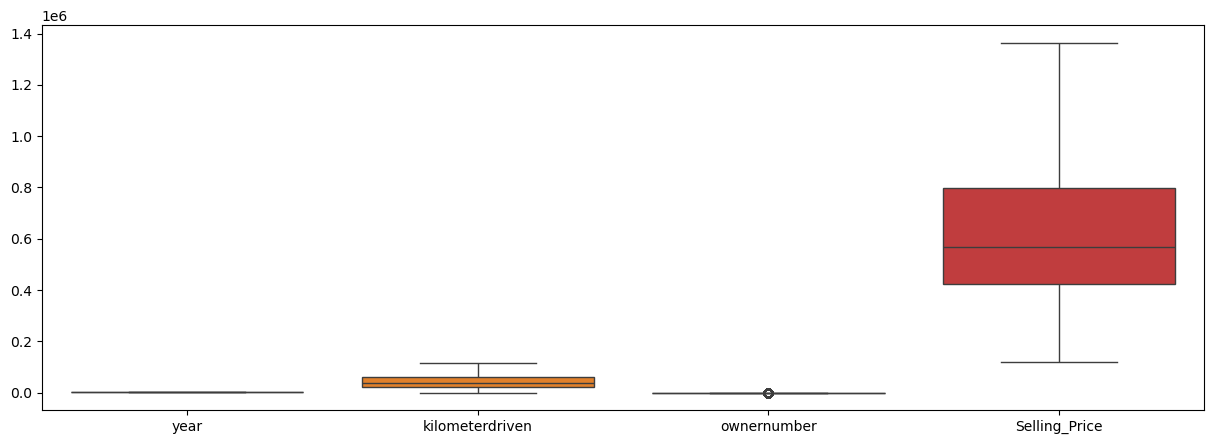

In [58]:
plt.figure(figsize=(15, 5))
sns.boxplot(cars_df_new)
plt.show()
#Plot Boxplot For Outlier Detection After Capping

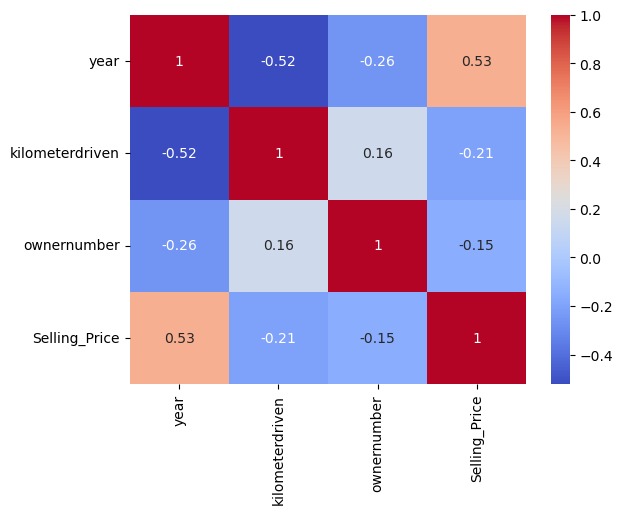

In [59]:
sns.heatmap(cars_df_new.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [60]:
cars_df_new.sample(10)

,make,model,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,registrationcity,registrationstate,Selling_Price
1390,Mahindra,Xuv 3Oo,2021.0,Petrol,9288.0,1,Manual,Hatchback,Jaipur,Rajasthan,1212600.0
2352,Maruti,Wagon R 1.0,2018.0,Petrol,20567.0,1,Manual,Hatchback,Delhi,Delhi,445000.0
3898,Honda,Brio,2015.0,Petrol,97316.0,1,Manual,Hatchback,Hyderabad,Telangana,371500.0
4651,Hyundai,Grand I10,2018.0,Petrol,46674.0,1,Manual,Hatchback,Dewas,Madhya Pradesh,543000.0
3194,Kia,Seltos,2020.0,Petrol,26757.0,1,Automatic,SUV,Mumbai Atc,Maharashtra,1364800.0
5208,Maruti,Ignis,2020.0,Petrol,33417.0,1,Automatic,Hatchback,Jaipur,Rajasthan,793000.0
1719,Mg,Hector,2020.0,Petrol,18555.0,1,Automatic,SUV,Hyderabad,Telangana,1364800.0
5558,Maruti,Alto,2021.0,Petrol,7607.0,1,Manual,Hatchback,Hyderabad,Telangana,435000.0
5132,Maruti,Dzire,2020.0,Petrol,52854.0,1,Manual,Sedan,Muzaffarpur,Bihar,606000.0
5395,Hyundai,I10,2013.0,Petrol,55166.0,1,Manual,Hatchback,Hyderabad,Telangana,369000.0


Encoding Categorical Features

In [61]:
!pip install category_encoders
#importing the required libraries
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X = cars_df_new.drop(columns=['Selling_Price'],axis=1) # Define features (X) by dropping the target variable 'price'
Y = cars_df_new['Selling_Price'] # Define target variable (Y) as 'price'

In [64]:
X

,make,model,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,registrationcity,registrationstate
0,Hyundai,Elite I20,2017.0,Petrol,35939.0,2,Manual,Hatchback,Kozhikode,Kerala
1,Maruti,Alto 800,2016.0,Petrol + Cng,6180.0,1,Manual,Hatchback,Mumbai,Maharashtra
2,Maruti,Dzire,2019.0,Petrol + Cng,46808.0,1,Manual,Sedan,Lucknow,Uttar Pradesh
3,Kia,Seltos,2020.0,Diesel,26045.0,1,Manual,SUV,Bengaluru,Karnataka
4,Maruti,Ertiga,2017.0,Petrol,53056.0,1,Manual,SUV,Barrackpore,West Bengal
...,...,...,...,...,...,...,...,...,...,...
6432,Mahindra,Xuv500,2013.0,Diesel,74570.0,2,Manual,SUV,Hyderabad,Telangana
6433,Renault,Kwid,2017.0,Petrol,39981.0,2,Manual,Hatchback,Faridabad,Haryana
6434,Hyundai,I10,2014.0,Petrol,61249.0,1,Manual,Hatchback,Hyderabad,Telangana
6435,Maruti,Swift Dzire,2014.0,Petrol,48081.0,1,Manual,Sedan,Hyderabad,Telangana


In [65]:
Y

0        559601.0
1        323901.0
2        614000.0
3       1210300.0
4        653200.0
          ...    
6432     744000.0
6433     248000.0
6434     351000.0
6435     494000.0
6436     371000.0
Name: Selling_Price, Length: 6422, dtype: float64

In [66]:
# Split the data into training and testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5137, 10)
(1285, 10)
(5137,)
(1285,)


In [67]:
more_cat_cols = ['make', 'model','registrationcity','registrationstate'] #columns with more categories for target encoding
less_cat_cols = ['fueltype','transmission','bodytype'] #columns with fewer categories for one-hot encoding

In [68]:
# Create a column transformer with both encoders
#code from Kaggle: https://www.kaggle.com/code/aichabokbot/encoding-high-cardinality-categorical-features#Target-encoding
enc = ColumnTransformer([
    ('target', TargetEncoder(cols=more_cat_cols), more_cat_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), less_cat_cols)
], remainder='passthrough').fit(x_train, y_train)

X_train_encoded = enc.transform(x_train)
X_test_encoded = enc.transform(x_test)

In [69]:
X_train_encoded.shape

(5137, 17)

In [70]:
X_train = pd.DataFrame(X_train_encoded)

In [71]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,621949.853767,477284.763578,620554.775362,622415.556468,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2016.0,49960.0,1.0
1,621949.853767,814411.009818,711115.646245,713378.419195,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2020.0,22429.0,2.0
2,520272.469201,528877.116056,837962.120086,698002.676942,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2018.0,43573.0,1.0
3,520272.469201,361294.088561,712176.582452,698633.335065,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2019.0,19844.0,1.0
4,520272.469201,538995.301162,636058.446884,665259.467014,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2018.0,52330.0,1.0


In [72]:
X_test = pd.DataFrame(X_test_encoded)

In [73]:
X_test.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,520272.469201,538995.301162,672338.850917,698002.676942,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2013.0,52458.0,1.0
1,520272.469201,380526.026840,640400.652968,640400.652968,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2019.0,33806.0,2.0
2,838856.114817,531201.811451,670635.666665,655575.350198,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2017.0,29165.0,1.0


In [74]:
y_train.head()

2346    485000.0
509     960000.0
5463    731000.0
4588    378000.0
5147    658000.0
Name: Selling_Price, dtype: float64

In [75]:
y_test.head()

324     506701.0
1340    405000.0
6028    470400.0
2077    402300.0
381     350000.0
Name: Selling_Price, dtype: float64

## Feature Scaling

In [76]:
# This cell previously contained incorrect scaling steps. The correct scaling is now handled in the next cell.

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Instantiate StandardScaler once

# Fit the scaler on the *encoded but unscaled* training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform the encoded test data using the fitted scaler
X_test_scaled = scaler.transform(X_test_encoded)

# Update X_train and X_test for subsequent model training to use the correctly scaled data
X_train = X_train_scaled
X_test = X_test_scaled

In [78]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(5137, 17)
(1285, 17)
(5137,)
(1285,)


## Model Training and Evaluation

# Model1:Linear Regression

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()

In [80]:
lr.fit(X_train_scaled, y_train) # Train the Linear Regression model on the training data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
y_pred_lr = lr.predict(X_test) # Predict the target variable for the test set

In [82]:
print(f'Linear Regression - Evaluation Metrics')
print("=======================================")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lr)) # Calculate and print the Mean Squared Error
print("R-squared Score:", r2_score(y_test, y_pred_lr)) # Calculate and print the R-squared Score to evaluate the model's performance

Linear Regression - Evaluation Metrics
Mean Squared Error: 15096598985.527723
R-squared Score: 0.8284747930449057


In [83]:
m1_lr=lr.score(X_train_scaled, y_train) # Get the R-squared score of the model on the training data

In [84]:
print("=======================================")
print(f"Linear Regression Model Score:: {m1_lr* 100:.2f}%")

Linear Regression Model Score:: 84.53%


## Model 2: XGBoost

In [85]:
!pip install xgboost
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [86]:
y_pred_xgb = xgb.predict(X_test) # Predict the target variable for the test set using XGBoost model
print(f'XGBoosting - Evaluation Metrics')
print("=======================================")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb)) # Calculate and print the Mean Squared Error for XGBoost model
print("R-squared Score:", r2_score(y_test, y_pred_xgb)) # Calculate and print the R-squared Score for XGBoost model to evaluate its performance

XGBoosting - Evaluation Metrics
Mean Squared Error: 5888491223.102402
R-squared Score: 0.9330958796306273


In [87]:
m2_xgboost=xgb.score(X_train_scaled, y_train) # Get the R-squared score of the XGBoost model on the training data

In [88]:
print("=======================================")
print(f"XGboost Model Score:: {m2_xgboost* 100:.2f}%")

XGboost Model Score:: 98.59%


## Model 3 :GradientBoosting

In [89]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Training
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [90]:
# Model Prediction
y_pred_gbr = gbr_model.predict(X_test)

# Model Evaluation
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
print(f'Gradient Boosting - Evaluation Metrics')
print("=======================================")
print(f'Mean Squared Error: {mse_gbr}')
print(f'R-Squared score: {r2_gbr}')

Gradient Boosting - Evaluation Metrics
Mean Squared Error: 9199756391.999851
R-Squared score: 0.8954738003846456


In [91]:
m3_gbr=gbr_model.score(X_train_scaled, y_train)

In [92]:
print("=======================================")
print(f"Gradient Boosting Model Score:: {m3_gbr* 100:.2f}%")

Gradient Boosting Model Score:: 91.81%


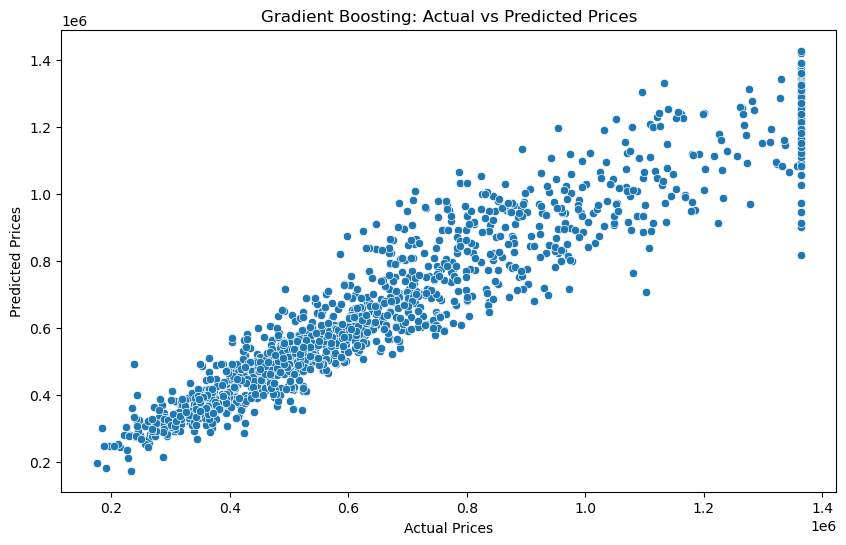

In [93]:
# Plotting Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Gradient Boosting: Actual vs Predicted Prices')
plt.show()

## Model 4: Random Forest Model

In [94]:
from sklearn.ensemble import RandomForestRegressor
# Model Training
rfm_model = RandomForestRegressor(random_state=42)
rfm_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
y_pred_rfm = rfm_model.predict(X_test) # Predict the target variable for the test set

In [96]:
# Model Evaluation
mse_rfm = mean_squared_error(y_test, y_pred_rfm)
mae_rfm = mean_absolute_error(y_test, y_pred_rfm)
r2_rfm = r2_score(y_test, y_pred_rfm)
print(f'Gradient Boosting - Evaluation Metrics')
print("=======================================")
print(f'Mean Squared Error: {mse_rfm}')
print(f'R-Squared score: {r2_rfm}')

Gradient Boosting - Evaluation Metrics
Mean Squared Error: 7005593680.42719
R-Squared score: 0.9204035354565279


In [97]:
m4_rfm=rfm_model.score(X_train_scaled, y_train)

In [98]:
print("=======================================")
print(f"Random Forest Model Score:: {m4_rfm* 100:.2f}%")

Random Forest Model Score:: 98.81%


# Model 5: KNN Regressor

In [99]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [100]:
knn_regressor_model=make_regression

In [101]:
make_regression = KNeighborsRegressor(n_neighbors=5)
make_regression.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [102]:
y_pred_knn_r = make_regression.predict(X_test) # Predict the target variable for the test set

In [103]:
mse_knn = mean_squared_error(y_test, y_pred_knn_r)
mae_knn = mean_absolute_error(y_test, y_pred_knn_r)
r2_knn = r2_score(y_test, y_pred_knn_r)
print(f'KNN Regressor - Evaluation Metrics')
print("=======================================")
print(f'Mean Squared Error: {mse_knn}')
print(f'R-Squared score: {r2_knn}')

KNN Regressor - Evaluation Metrics
Mean Squared Error: 12750700555.05491
R-Squared score: 0.8551285257278908


In [104]:
m5_knn=make_regression.score(X_train_scaled, y_train)

In [105]:
print("=======================================")
print(f"KNN Regressor Model Score:: {m5_knn* 100:.2f}%")

KNN Regressor Model Score:: 90.15%


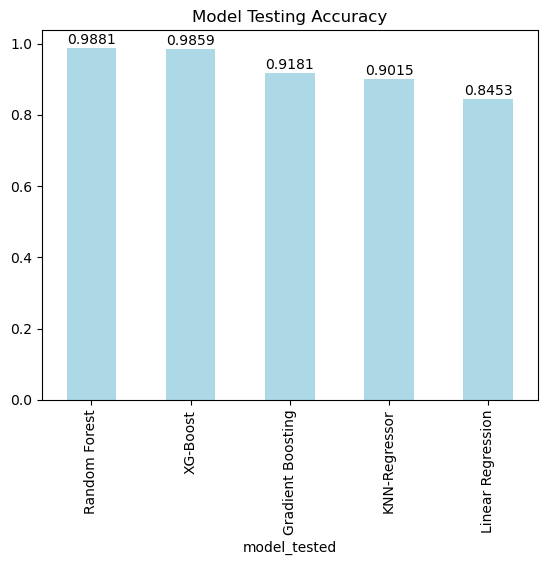

In [106]:
data = {
   'model_tested' :['Linear Regression', 'XG-Boost', 'Gradient Boosting', 'Random Forest','KNN-Regressor'],
   'model_acc' :[m1_lr, m2_xgboost, m3_gbr, m4_rfm,m5_knn]
}
df = pd.DataFrame(data)
# Sort the DataFrame by 'Value' in descending order
df = df.sort_values(by='model_acc', ascending=False)

# Using pandas plot() function
ax1 = df.plot(kind='bar', x='model_tested', y='model_acc',legend=None,color='lightblue')
ax1.set_title('Model Testing Accuracy')
# Add value labels on top of each bar
for i, v in enumerate(df['model_acc']):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.show()

## Other Possible Models that can be applied
5.ANN
6.KNN Regressor
7.Adaboost
8.Bagging

## As Random Forest has maximum Accuracy , we will go ahead with deploying Random Forest

In [107]:
import pickle

In [108]:
pickle.dump(rfm_model,open('artifacts/random_forest_model.pkl','wb'))

## Saving the Cleaned and Processed data

In [109]:
cars_df.to_csv('data/raw_cars_data.csv', index=False)

In [110]:
cars_df_new.to_csv('data/cleaned_cars_data.csv', index=False)

### Saving Preprocessing Objects and Model

To ensure consistent preprocessing for new data when making predictions with the Flask app, we will save the `StandardScaler` and `ColumnTransformer` objects that were fitted on our training data. `rfm_model` was already saved and have been included  here for completeness.

In [111]:
# Re-saving the StandardScaler and ColumnTransformer objects

pickle.dump(scaler, open('artifacts/scaler.pkl', 'wb'))
pickle.dump(enc, open('artifacts/column_transformer.pkl', 'wb'))

print("Scaler and ColumnTransformer re-saved successfully.")

Scaler and ColumnTransformer re-saved successfully.


In [112]:
# Re-save the Random Forest model
import pickle
pickle.dump(rfm_model, open('artifacts/random_forest_model.pkl', 'wb'))
print("Random Forest Model re-saved.")

Random Forest Model re-saved.


Readme

In [113]:
readme_content = """
# Car Price Prediction Project

## Project Overview
This project predicts used car prices using Machine Learning techniques on the Cars24 dataset.  
The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and deployment using a Streamlit web application.

The best-performing model selected for deployment is:

- Random Forest Regressor

## Table of Contents
1. [Project Structure](#project-structure)
2. [Dataset](#dataset)
3. [Data Preprocessing and Feature Engineering](#data-preprocessing-and-feature-engineering)
4. [Models Used](#models-used)
5. [Streamlit Application Setup](#streamlit-application-setup)
6. [How to Run the Streamlit Application](#how-to-run-the-streamlit-application)

## Project Structure
# Project Root
├── streamlit_app.py
├── car_price_prediction_withStreamlit.ipynb
│
├── data/
│ ├── cars24_data.csv
│ └── cleaned_cars_data.csv
│
├── artifacts/
│ ├── random_forest_model.pkl
│ ├── scaler.pkl
│ └── column_transformer.pkl
│
└── README.md

## Dataset
The dataset `cars24_data.csv` contains used car information such as:

- make
- model
- year
- fueltype
- transmission
- bodytype
- kilometerdriven
- ownernumber
- registrationcity
- registrationstate
- selling price

The raw dataset is cleaned and transformed during preprocessing.

## Data Preprocessing and Feature Engineering
The following preprocessing steps were performed:

- Handling missing values
- Removing duplicate records
- Feature engineering
- Outlier handling
- Encoding categorical variables
- Scaling numerical features

### Encoding Techniques
- Target Encoding
- One Hot Encoding

### Feature Scaling
- StandardScaler

## Models Used
Several regression models were trained and evaluated:

- Linear Regression
- Gradient Boosting Regressor
- Random Forest Regressor
- XGBoost Regressor
- KNeighbors Regressor

### Best Model
Random Forest Regressor achieved the best performance and was selected for deployment.

## Streamlit Application Setup
The project uses a Streamlit web application (`streamlit_app.py`) to predict car prices.

The application loads:

- Random Forest model
- StandardScaler
- ColumnTransformer

from the `artifacts` folder for preprocessing and prediction.

The UI allows users to:

- Select car make
- Select model
- Choose fuel type
- Select transmission
- Enter kilometers driven
- Predict car selling price

## Recommended Python Version
This project is recommended to run on:

```text
Python 3.11
Create Virtual Environment

Open terminal inside project folder and run:

py -3.11 -m venv .venv

Activate virtual environment:

.venv\\Scripts\\activate
Install Required Libraries

Install all required dependencies:

pip install pandas numpy scikit-learn==1.6.1 streamlit category_encoders xgboost matplotlib seaborn joblib
Run the Notebook

Open:

car_price_prediction_withStreamlit.ipynb

Run all notebook cells.

This will generate:

artifacts/random_forest_model.pkl
artifacts/scaler.pkl
artifacts/column_transformer.pkl
How to Run the Streamlit Application
Ensure all notebook cells have been executed successfully.
Ensure all .pkl files are available inside the artifacts folder.
Open terminal inside project folder.

Run:

python -m streamlit run streamlit_app.py
Access the Application

After running Streamlit, open:

http://localhost:8501

in your browser.

Important Notes
The .pkl files and installed sklearn version must match.
This project uses:
scikit-learn==1.6.1
Using a different sklearn version may cause compatibility issues.
Author

Aparna Rajesh

Artificial Intelligence and Machine Learning Student
"""


In [114]:

with open('README.md', 'w') as f:
 f.write(readme_content)

print("Created README.md")

Created README.md


In [115]:
streamlit_app_py_content = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor # Added this import for type checking
import os

# --- 1. Streamlit App Configuration ---
st.set_page_config(layout="wide")
st.title('Car Price Predictor')

# --- 2. Load Model and Preprocessing Objects (Cached for Efficiency) ---
@st.cache_resource
def load_artifacts():
    try:
        model = pickle.load(open('artifacts/random_forest_model.pkl', 'rb'))
        # Add a type check for the loaded model
        if not isinstance(model, RandomForestRegressor):
            st.error(f"Error: Loaded model is not a RandomForestRegressor. Type is {type(model)}")
            st.stop()

        scaler = pickle.load(open('artifacts/scaler.pkl', 'rb'))
        column_transformer = pickle.load(open('artifacts/column_transformer.pkl', 'rb'))
        return model, scaler, column_transformer
    except Exception as e:
        st.error(f"Error loading model or preprocessing objects: {e}")
        st.stop()

model, scaler, column_transformer = load_artifacts()

# --- 3. Load Unique Values for Dropdowns (Cached for Efficiency) ---
@st.cache_data
def load_unique_values():
    try:
        # Assuming 'data/cleaned_cars_data.csv' contains the preprocessed data
        # from which unique categories can be derived.
        cleaned_df = pd.read_csv('data/cleaned_cars_data.csv')
        return {
            'make': sorted(cleaned_df['make'].unique()),
            'model': sorted(cleaned_df['model'].unique()),
            'year': sorted(cleaned_df['year'].unique().astype(int)),
            'ownernumber': sorted(cleaned_df['ownernumber'].unique().astype(int)),
            'fueltype': sorted(cleaned_df['fueltype'].unique()),
            'transmission': sorted(cleaned_df['transmission'].unique()),
            'bodytype': sorted(cleaned_df['bodytype'].unique()),
            'registrationcity': sorted(cleaned_df['registrationcity'].unique()),
            'registrationstate': sorted(cleaned_df['registrationstate'].unique())
        }
    except Exception as e:
        st.error(f"Error loading cleaned_cars_data.csv or extracting unique values: {e}")
        st.stop()

unique_values = load_unique_values()

# --- 4. Streamlit Input Form for Car Details ---
with st.form("prediction_form"):
    st.header("Enter Car Details")

    col1, col2, col3 = st.columns(3)

    with col1:
        make = st.selectbox('Make', unique_values['make'])
        model_input = st.selectbox('Model', unique_values['model']) # Renamed to avoid conflict with 'model' variable
        year = st.selectbox('Year', unique_values['year'])

    with col2:
        fueltype = st.selectbox('Fuel Type', unique_values['fueltype'])
        kilometerdriven = st.number_input('Kilometer Driven', min_value=0, value=50000, step=1000)
        ownernumber = st.selectbox('Owner Number', unique_values['ownernumber'])

    with col3:
        transmission = st.selectbox('Transmission', unique_values['transmission'])
        bodytype = st.selectbox('Body Type', unique_values['bodytype'])
        registrationcity = st.selectbox('Registration City', unique_values['registrationcity'])
        registrationstate = st.selectbox('Registration State', unique_values['registrationstate'])

    submit_button = st.form_submit_button("Predict Price")

    # --- 5. Prediction Logic (Executed on Form Submission) ---
    if submit_button:
        input_data = pd.DataFrame([{ # Create DataFrame from user inputs
            'make': make,
            'model': model_input, # Use model_input here
            'year': year,
            'fueltype': fueltype,
            'kilometerdriven': float(kilometerdriven),
            'ownernumber': int(ownernumber),
            'transmission': transmission,
            'bodytype': bodytype,
            'registrationcity': registrationcity,
            'registrationstate': registrationstate
        }])

        try:
            # Apply transformations using the loaded preprocessing objects
            # The column_transformer handles both target and one-hot encoding
            input_encoded = column_transformer.transform(input_data)

            # Scale numerical features using the loaded StandardScaler
            input_scaled = scaler.transform(input_encoded)

            # Make prediction using the loaded model
            prediction = model.predict(input_scaled)[0]
            st.success(f'Predicted Selling Price: ₹{prediction:,.2f}')
        except Exception as e:
            st.error(f"Error during prediction: {e}")

# To run this app:
# 1. Ensure all .pkl files and cleaned_cars_data.csv are in their respective directories ('artifacts', 'data').
# 2. Save this code as `streamlit_app.py`.
# 3. Open a terminal in your environment and run: `streamlit run streamlit_app.py`
"""

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_app_py_content)

print("Created streamlit_app.py with execution sequence comments")

Created streamlit_app.py with execution sequence comments


In [116]:
!pip install streamlit

In [ ]:
!streamlit run streamlit_app.py

In [ ]:
import os
from pyngrok import ngrok

# Terminate open tunnels if any
ngrok.kill()

# Optional: Set your ngrok auth token if you have one for persistent tunnels
# You can get one from ngrok.com after signing up
# os.environ["NGROK_AUTH_TOKEN"] = "YOUR_AUTH_TOKEN_HERE"

# Start ngrok tunnel for Streamlit on port 8501
public_url = ngrok.connect(addr="8501", bind_tls=True)
print(f"Streamlit app will be available at: {public_url}")

Streamlit app will be available at: NgrokTunnel: "https://shavonne-crumply-jemma.ngrok-free.dev" -> "http://localhost:8501"
